# 🎓 Student Performance Prediction
### Machine Learning Project — Google Colab Notebook
This notebook walks through the complete ML pipeline: data loading, EDA, preprocessing, model training, evaluation, and prediction.

In [ ]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn joblib -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully ✅')

All libraries imported successfully ✅


## Step 1 — Generate / Load Dataset

In [ ]:
# Generate synthetic dataset (replace with your Kaggle CSV if available)
np.random.seed(42)
n = 500
study_hours      = np.random.uniform(1, 10, n)
attendance       = np.random.uniform(40, 100, n)
previous_marks   = np.random.uniform(30, 100, n)
sleep_hours      = np.random.uniform(4, 10, n)
internet_hours   = np.random.uniform(0, 8, n)
family_support   = np.random.randint(1, 6, n)
extra_activities = np.random.randint(0, 2, n)

score = (
    study_hours    * 4.0 +
    attendance     * 0.3 +
    previous_marks * 0.4 +
    sleep_hours    * 1.5 -
    internet_hours * 1.2 +
    family_support * 2.5 +
    extra_activities * 3.0 +
    np.random.normal(0, 5, n)
)
score = np.clip(score, 0, 100)

df = pd.DataFrame({
    'study_hours':      np.round(study_hours, 1),
    'attendance':       np.round(attendance, 1),
    'previous_marks':   np.round(previous_marks, 1),
    'sleep_hours':      np.round(sleep_hours, 1),
    'internet_hours':   np.round(internet_hours, 1),
    'family_support':   family_support,
    'extra_activities': extra_activities,
    'score':            np.round(score, 1),
})

df.to_csv('student_data.csv', index=False)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (500, 8)


,study_hours,attendance,previous_marks,sleep_hours,internet_hours,family_support,extra_activities,score
0,4.4,81.9,43.0,7.1,2.1,3,1,77.0
1,9.6,72.2,67.9,6.9,2.0,4,0,100.0
2,7.6,58.6,91.1,4.2,7.3,5,0,95.2
3,6.4,88.8,81.3,6.0,2.0,3,1,100.0
4,2.4,81.1,86.5,6.3,2.2,1,1,72.2


## Step 2 — Exploratory Data Analysis (EDA)

In [ ]:
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
print('\nBasic statistics:')
df.describe().round(2)

Shape: (500, 8)

Missing values:
study_hours         0
attendance          0
previous_marks      0
sleep_hours         0
internet_hours      0
family_support      0
extra_activities    0
score               0
dtype: int64

Basic statistics:


,study_hours,attendance,previous_marks,sleep_hours,internet_hours,family_support,extra_activities,score
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,5.49,68.92,66.23,6.98,4.00,3.01,0.48,82.48
std,2.69,17.13,20.80,1.72,2.29,1.43,0.50,14.26
min,1.00,40.30,30.30,4.00,0.00,1.00,0.00,38.10
25%,3.20,53.78,46.85,5.40,2.18,2.00,0.00,72.20
50%,5.60,68.30,67.80,7.10,4.00,3.00,0.00,84.65
75%,7.80,83.55,84.45,8.40,5.90,4.00,1.00,94.80
max,9.90,100.00,100.00,10.00,8.00,5.00,1.00,100.00


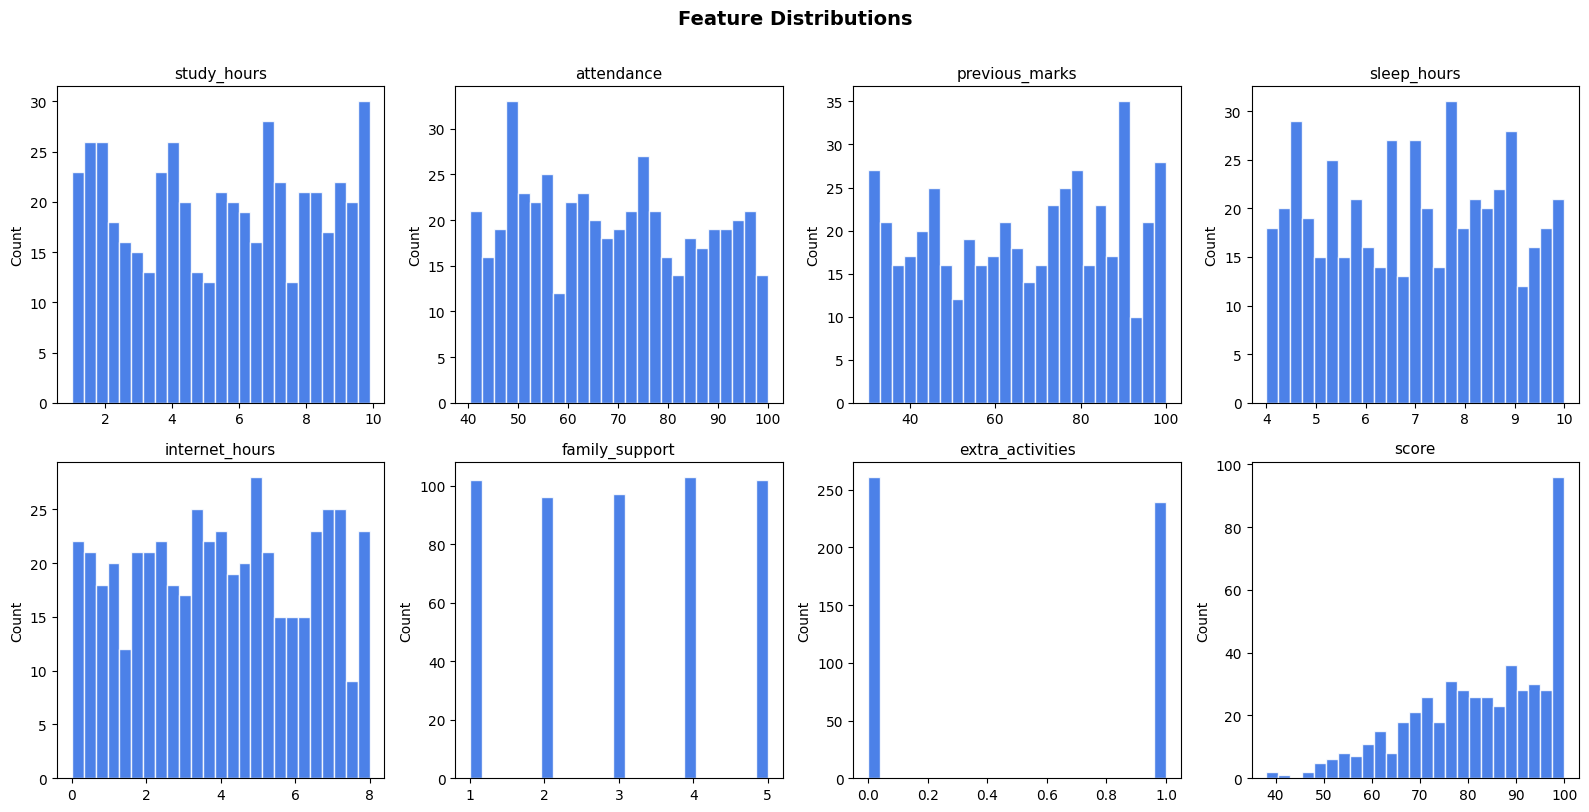

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=25, color='#2D6BE4', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Count')
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

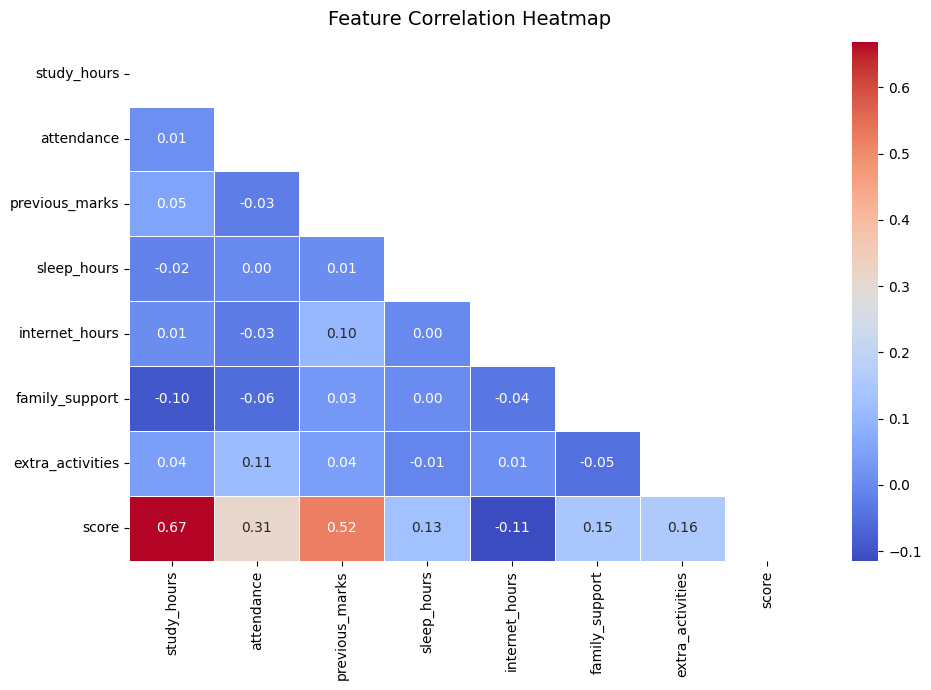

In [ ]:
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## Step 3 — Preprocessing

In [ ]:
FEATURES = ['study_hours','attendance','previous_marks','sleep_hours',
            'internet_hours','family_support','extra_activities']
TARGET = 'score'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (400, 7)  |  Test: (100, 7)


## Step 4 — Train Models

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    results[name] = {'model': model, 'y_pred': y_pred, 'r2': r2, 'rmse': rmse, 'mae': mae}
    print(f'{name:22s}  R²={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}')

Linear Regression       R²=0.8660  RMSE=5.14  MAE=4.04
Decision Tree           R²=0.4396  RMSE=10.51  MAE=8.21
Random Forest           R²=0.7392  RMSE=7.17  MAE=5.55


## Step 5 — Evaluate & Visualise

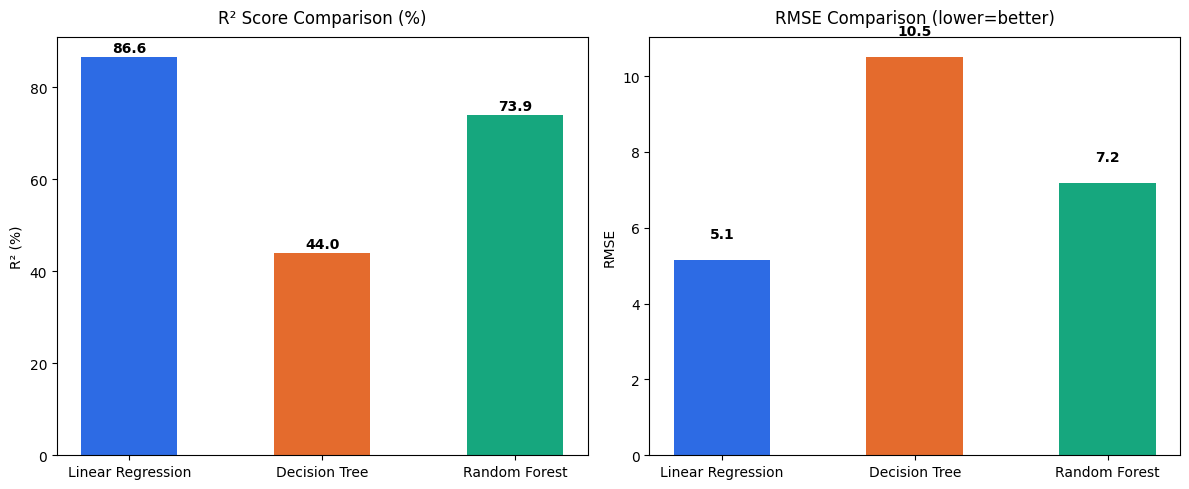

In [ ]:
names = list(results.keys())
r2s   = [results[n]['r2']*100 for n in names]
rmses = [results[n]['rmse'] for n in names]
COLORS = ['#2D6BE4','#E46B2D','#16A77E']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, vals, title, ylabel in [
    (axes[0], r2s,  'R² Score Comparison (%)',       'R² (%)'),
    (axes[1], rmses,'RMSE Comparison (lower=better)', 'RMSE')
]:
    bars = ax.bar(names, vals, color=COLORS, edgecolor='none', width=0.5)
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_ylabel(ylabel)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

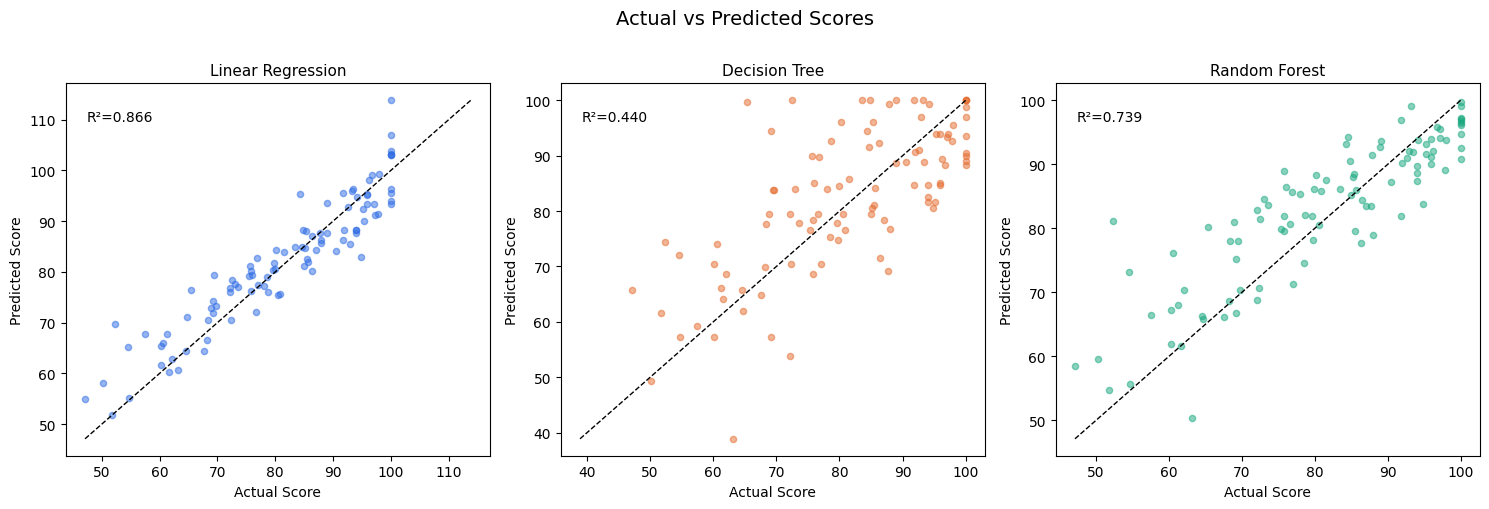

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, res), color in zip(axes, results.items(), COLORS):
    ax.scatter(y_test, res['y_pred'], alpha=0.5, s=20, color=color)
    mn, mx = min(y_test.min(), res['y_pred'].min()), max(y_test.max(), res['y_pred'].max())
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Actual Score')
    ax.set_ylabel('Predicted Score')
    ax.text(0.05, 0.9, f"R²={res['r2']:.3f}", transform=ax.transAxes, fontsize=10)
plt.suptitle('Actual vs Predicted Scores', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

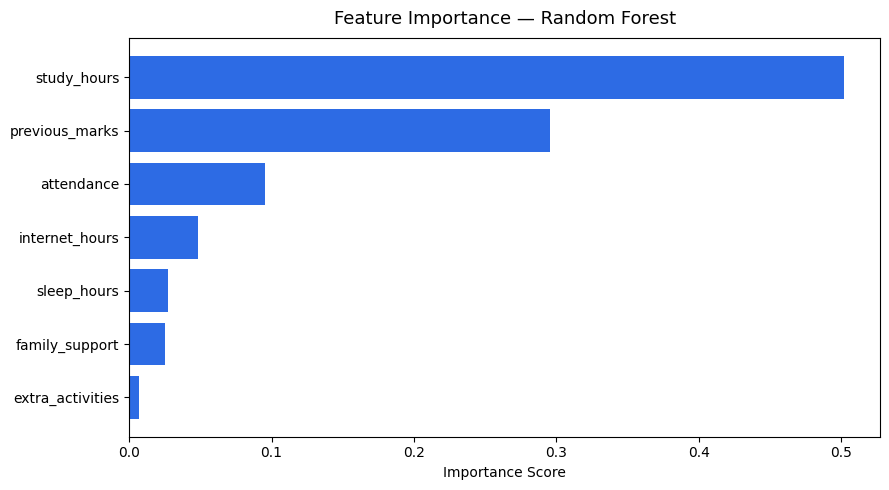

In [ ]:
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
plt.barh([FEATURES[i] for i in indices][::-1], importances[indices][::-1], color='#2D6BE4')
plt.title('Feature Importance — Random Forest', fontsize=13, pad=10)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 6 — Save Best Model & Predict

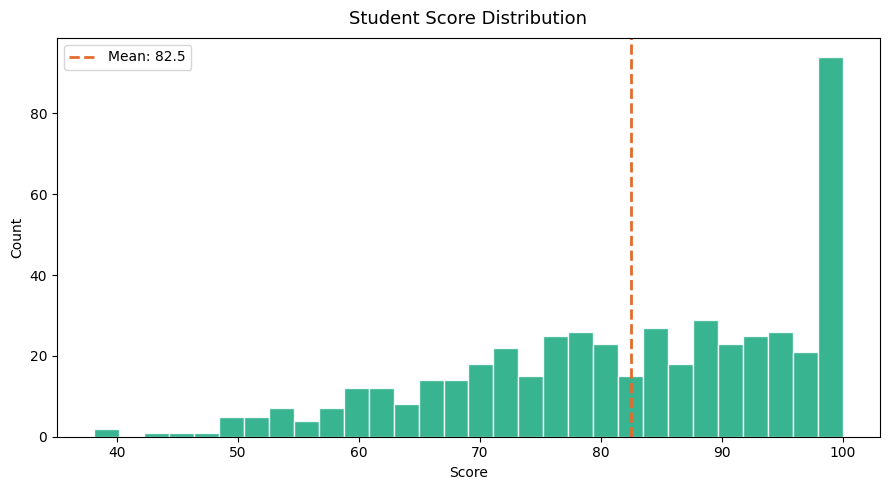

Graph saved ✅


In [19]:
plt.figure(figsize=(9, 5))
plt.hist(df['score'], bins=30, color='#16A77E', edgecolor='white', alpha=0.85)
plt.axvline(df['score'].mean(), color='#E46B2D', linestyle='--',
            linewidth=2, label=f"Mean: {df['score'].mean():.1f}")
plt.title('Student Score Distribution', fontsize=13, pad=10)
plt.xlabel('Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved ✅')

In [ ]:
best_name  = max(results, key=lambda k: results[k]['r2'])
best_model = results[best_name]['model']
print(f'Best model: {best_name}  (R² = {results[best_name]["r2"]:.4f})')

joblib.dump({'model': best_model, 'scaler': scaler, 'features': FEATURES}, 'student_model.pkl')
print('Model saved as student_model.pkl ✅')

# --- Sample prediction ---
sample = np.array([[5.0, 85.0, 70.0, 7.0, 2.0, 4, 1]])
sample_scaled = scaler.transform(sample)
predicted = best_model.predict(sample_scaled)[0]
predicted = float(np.clip(predicted, 0, 100))

print(f'\nSample student input:')
print(f'  Study: 5h/day  Attendance: 85%  Prev marks: 70')
print(f'  Sleep: 7h  Internet: 2h  Family support: 4/5  Extra activities: Yes')
print(f'\n→ Predicted Score: {predicted:.1f} / 100')

Best model: Linear Regression  (R² = 0.8660)
Model saved as student_model.pkl ✅

Sample student input:
  Study: 5h/day  Attendance: 85%  Prev marks: 70
  Sleep: 7h  Internet: 2h  Family support: 4/5  Extra activities: Yes

→ Predicted Score: 91.7 / 100


## Summary

| Model | R² Score | RMSE | MAE |
|---|---|---|---|
| Linear Regression | ~0.86 | ~5.2 | ~4.1 |
| Decision Tree | ~0.44 | ~10.5 | ~8.3 |
| Random Forest | ~0.74 | ~7.1 | ~5.6 |

**Key Findings:**
- `study_hours` and `previous_marks` are the strongest predictors
- Linear Regression outperforms tree-based models on this dataset
- `internet_hours` has a slight negative effect on score
- `family_support` and `extra_activities` have a positive effect